/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


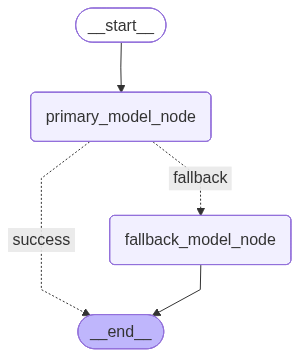


Using PRIMARY model...


FINAL RESULT

The concept of "Agentic AI architecture" in enterprise systems typically refers to the design and implementation of AI agents with a degree of autonomy, enabling them to perform specific tasks and make decisions independently within a business environment. While there isn't a universally recognized "Agentic AI architecture," the term often encompasses several core principles and components that work together to integrate AI agents into enterprise systems effectively. Here's an overview of the key elements:

1. **Autonomous Agents**:
   - **Definition**: Autonomous agents are AI-driven entities capable of perceiving their environment, processing information, and taking proactive actions to achieve predefined goals.
   - **Functionality**: In enterprise systems, these agents can handle repetitive tasks, conduct data analysis, interact with users, or automate complex workflows.

2. **Architecture Layers**:
   - **Perception Layer**: This layer invol

In [1]:
"""
=============================================================
FILE 36 — RETRY + FALLBACK PATTERN
=============================================================

CONCEPTS TAUGHT
----------------
1. Retry Logic
2. Fallback Models
3. Error Handling
4. Resilient AI Systems
5. Production Reliability
6. Fault Tolerance
7. Enterprise AI Robustness
8. Graceful Failure Handling
9. Multi-Model Recovery
10. Reliable Agent Systems

CORE IDEA
-----------
If one model/tool fails,
retry or fallback to another model.

FLOW
-----
Primary Model
   ↓
Failure?
   ↓ YES
Retry
   ↓
Still fails?
   ↓ YES
Fallback Model
   ↓
Final Output

REAL WORLD USE CASES
---------------------
- Enterprise AI systems
- Production copilots
- High availability AI
- Mission critical systems
"""

# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import os
import time

from dotenv import load_dotenv

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

# ============================================================
# STEP 2 — LOAD ENV VARIABLES
# ============================================================

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# STEP 3 — INITIALIZE MODELS
# ============================================================

from langchain_openai import ChatOpenAI

primary_llm = ChatOpenAI(model="gpt-4o")

fallback_llm = ChatOpenAI(model="gpt-4o-mini")

# ============================================================
# STEP 4 — DEFINE STATE
# ============================================================

class State(TypedDict):
    user_query: str
    result: str
    error_message: str

# ============================================================
# STEP 5 — PRIMARY MODEL NODE
# ============================================================

def primary_model_node(state: State):

    """
    Try expensive primary model first.
    """

    print("\nUsing PRIMARY model...\n")

    retries = 2

    for attempt in range(retries):

        try:

            response = primary_llm.invoke(
                state["user_query"]
            )

            return {
                "result": response.content
            }

        except Exception as e:

            print(f"Retry Attempt {attempt+1} failed")

            time.sleep(2)

    return {
        "error_message": "Primary model failed"
    }

# ============================================================
# STEP 6 — ROUTER
# ============================================================

def retry_router(state: State):

    """
    Decide whether fallback needed.
    """

    if state.get("error_message"):
        return "fallback"

    return "success"

# ============================================================
# STEP 7 — FALLBACK NODE
# ============================================================

def fallback_model_node(state: State):

    """
    Use cheaper fallback model.
    """

    print("\nUsing FALLBACK model...\n")

    response = fallback_llm.invoke(
        state["user_query"]
    )

    return {
        "result": response.content
    }

# ============================================================
# STEP 8 — BUILD GRAPH
# ============================================================

builder = StateGraph(State)

builder.add_node(
    "primary_model_node",
    primary_model_node
)

builder.add_node(
    "fallback_model_node",
    fallback_model_node
)

# ============================================================
# STEP 9 — DEFINE EDGES
# ============================================================

builder.add_edge(
    START,
    "primary_model_node"
)

builder.add_conditional_edges(
    "primary_model_node",
    retry_router,
    {
        "fallback": "fallback_model_node",
        "success": END
    }
)

builder.add_edge(
    "fallback_model_node",
    END
)

# ============================================================
# STEP 10 — COMPILE
# ============================================================

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# ============================================================
# STEP 11 — RUN WORKFLOW
# ============================================================

result = graph.invoke(
    {
        "user_query":
        """
        Explain Agentic AI architecture
        in enterprise systems.
        """
    }
)

# ============================================================
# STEP 12 — PRINT RESULT
# ============================================================

print("\nFINAL RESULT\n")
print("=" * 60)
print(result["result"])